In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

matches = pd.read_csv('matches.csv')
deliveries = pd.read_csv('deliveries.csv')

print("Matches shape:", matches.shape)
print("Deliveries shape:", deliveries.shape)


Matches shape: (1095, 20)
Deliveries shape: (260920, 17)


In [2]:
matches.head()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


In [3]:
deliveries.head()

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN


In [4]:
print("=== MATCHES INFO ===")
print(matches.info())

print("\n=== DELIVERIES INFO ===")
print(deliveries.info())

=== MATCHES INFO ===
<class 'pandas.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               1095 non-null   int64  
 1   season           1095 non-null   str    
 2   city             1044 non-null   str    
 3   date             1095 non-null   str    
 4   match_type       1095 non-null   str    
 5   player_of_match  1090 non-null   str    
 6   venue            1095 non-null   str    
 7   team1            1095 non-null   str    
 8   team2            1095 non-null   str    
 9   toss_winner      1095 non-null   str    
 10  toss_decision    1095 non-null   str    
 11  winner           1090 non-null   str    
 12  result           1095 non-null   str    
 13  result_margin    1076 non-null   float64
 14  target_runs      1092 non-null   float64
 15  target_overs     1092 non-null   float64
 16  super_over       1095 non-null   str    
 17  meth

In [5]:
top_winners = matches['winner'].value_counts().head(10)
print(top_winners)

winner
Mumbai Indians                 144
Chennai Super Kings            138
Kolkata Knight Riders          131
Royal Challengers Bangalore    116
Rajasthan Royals               112
Kings XI Punjab                 88
Sunrisers Hyderabad             88
Delhi Daredevils                67
Delhi Capitals                  48
Deccan Chargers                 29
Name: count, dtype: int64


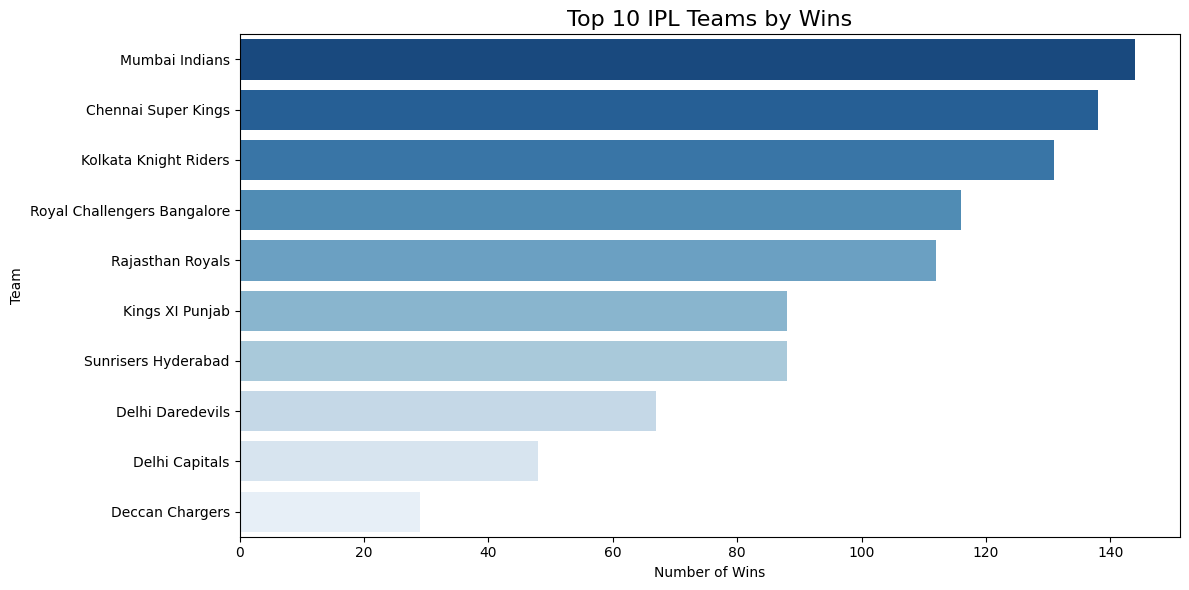

In [7]:
plt.figure(figsize=(12, 6))
sns.barplot(x=top_winners.values, y=top_winners.index, 
            hue=top_winners.index, palette='Blues_r', legend=False)
plt.title('Top 10 IPL Teams by Wins', fontsize=16)
plt.xlabel('Number of Wins')
plt.ylabel('Team')
plt.tight_layout()
plt.show()

In [8]:
top_batsmen = deliveries.groupby('batter')['batsman_runs'].sum().sort_values(ascending=False).head(10)
print(top_batsmen)


batter
V Kohli           8014
S Dhawan          6769
RG Sharma         6630
DA Warner         6567
SK Raina          5536
MS Dhoni          5243
AB de Villiers    5181
CH Gayle          4997
RV Uthappa        4954
KD Karthik        4843
Name: batsman_runs, dtype: int64


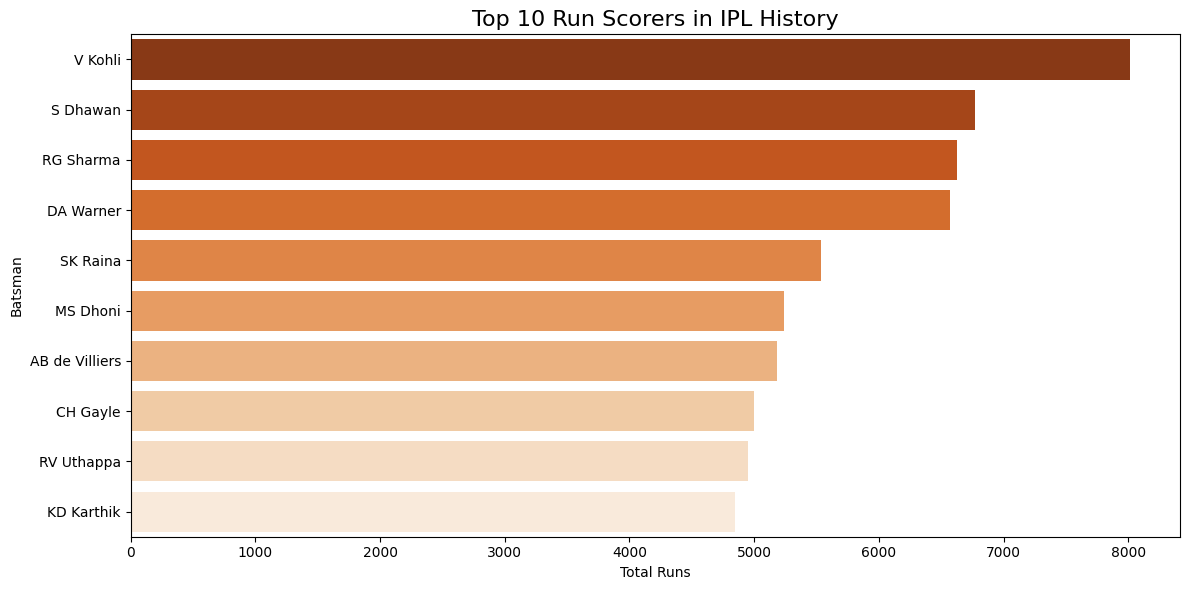

In [9]:
plt.figure(figsize=(12, 6))
sns.barplot(x=top_batsmen.values, y=top_batsmen.index,
            hue=top_batsmen.index, palette='Oranges_r', legend=False)
plt.title('Top 10 Run Scorers in IPL History', fontsize=16)
plt.xlabel('Total Runs')
plt.ylabel('Batsman')
plt.tight_layout()
plt.show()

In [10]:
top_bowlers = deliveries[deliveries['is_wicket'] == 1].groupby('bowler')['is_wicket'].count().sort_values(ascending=False).head(10)
print(top_bowlers)

bowler
YS Chahal     213
DJ Bravo      207
PP Chawla     201
SP Narine     200
R Ashwin      198
B Kumar       195
SL Malinga    188
A Mishra      183
JJ Bumrah     182
RA Jadeja     169
Name: is_wicket, dtype: int64


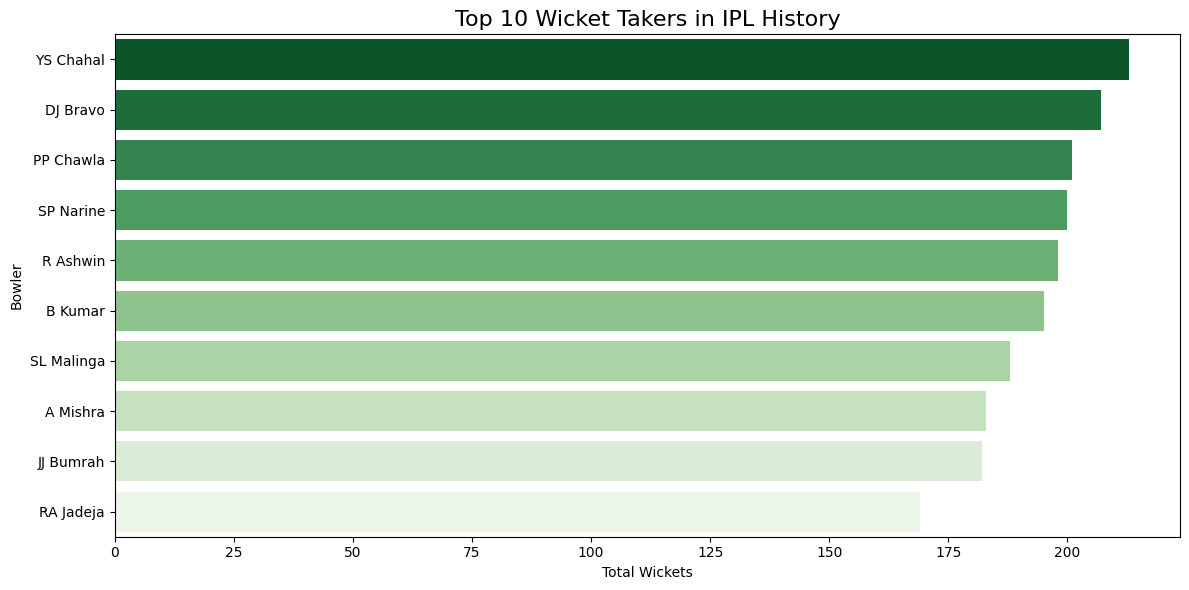

In [11]:
plt.figure(figsize=(12, 6))
sns.barplot(x=top_bowlers.values, y=top_bowlers.index,
            hue=top_bowlers.index, palette='Greens_r', legend=False)
plt.title('Top 10 Wicket Takers in IPL History', fontsize=16)
plt.xlabel('Total Wickets')
plt.ylabel('Bowler')
plt.tight_layout()
plt.show()

In [12]:
top_venues = matches['venue'].value_counts().head(10)
print(top_venues)

venue
Eden Gardens                                  77
Wankhede Stadium                              73
M Chinnaswamy Stadium                         65
Feroz Shah Kotla                              60
Rajiv Gandhi International Stadium, Uppal     49
MA Chidambaram Stadium, Chepauk               48
Sawai Mansingh Stadium                        47
Dubai International Cricket Stadium           46
Wankhede Stadium, Mumbai                      45
Punjab Cricket Association Stadium, Mohali    35
Name: count, dtype: int64


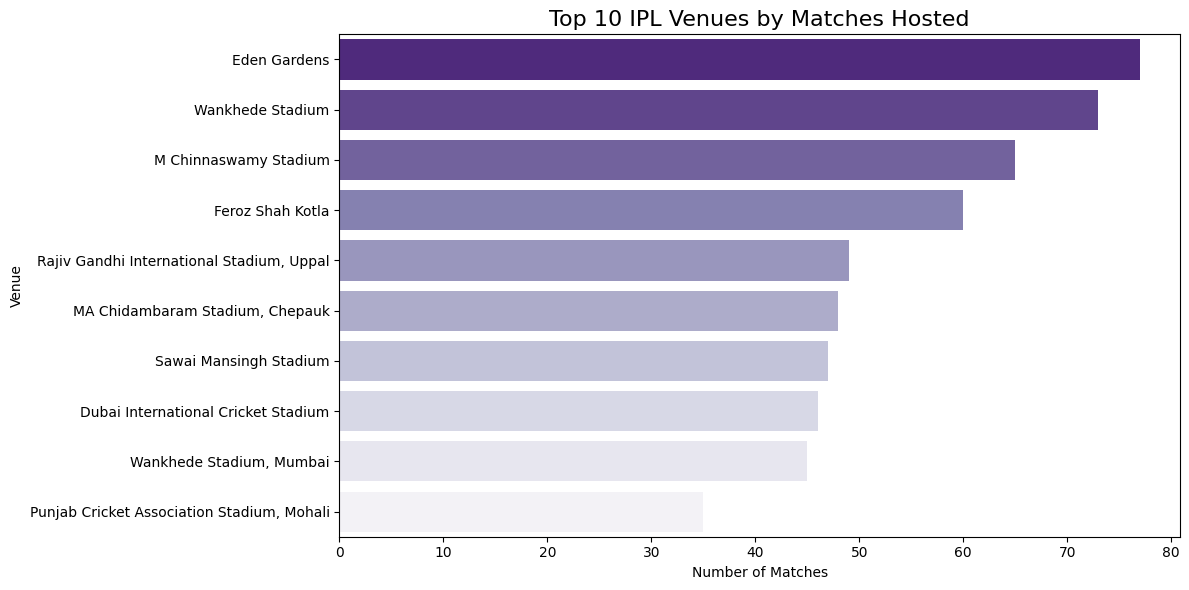

In [13]:
plt.figure(figsize=(12, 6))
sns.barplot(x=top_venues.values, y=top_venues.index,
            hue=top_venues.index, palette='Purples_r', legend=False)
plt.title('Top 10 IPL Venues by Matches Hosted', fontsize=16)
plt.xlabel('Number of Matches')
plt.ylabel('Venue')
plt.tight_layout()
plt.show()

In [14]:
print("=== Missing values in MATCHES ===")
print(matches.isnull().sum())

=== Missing values in MATCHES ===
id                    0
season                0
city                 51
date                  0
match_type            0
player_of_match       5
venue                 0
team1                 0
team2                 0
toss_winner           0
toss_decision         0
winner                5
result                0
result_margin        19
target_runs           3
target_overs          3
super_over            0
method             1074
umpire1               0
umpire2               0
dtype: int64


In [15]:
# Fill missing city with 'Unknown'
matches['city'] = matches['city'].fillna('Unknown')

# Fill missing winner with 'No Result'
matches['winner'] = matches['winner'].fillna('No Result')

# Fill missing player of match with 'None'
matches['player_of_match'] = matches['player_of_match'].fillna('None')

# Confirm no more missing values in these columns
print("Missing values after cleaning:")
print(matches[['city', 'winner', 'player_of_match']].isnull().sum())

Missing values after cleaning:
city               0
winner             0
player_of_match    0
dtype: int64


In [16]:
batsman_stats = deliveries.groupby('batter').agg(
    total_runs=('batsman_runs', 'sum'),
    total_balls=('batsman_runs', 'count')
).reset_index()

batsman_stats['strike_rate'] = (batsman_stats['total_runs'] / batsman_stats['total_balls'] * 100).round(2)

# Only keep batsmen with atleast 200 balls faced
batsman_stats = batsman_stats[batsman_stats['total_balls'] >= 200]

print(batsman_stats.sort_values('strike_rate', ascending=False).head(10))

             batter  total_runs  total_balls  strike_rate
433         PD Salt         653          385       169.61
606        T Stubbs         405          239       169.46
617         TM Head         772          458       168.56
39       AD Russell        2488         1515       164.22
208       H Klaasen         993          613       161.99
612        TH David         659          417       158.03
561       SP Narine        1534          984       155.89
585  Shashank Singh         423          272       155.51
396        N Pooran        1769         1143       154.77
323  LS Livingstone         939          609       154.19


In [17]:
bowler_stats = deliveries.groupby('bowler').agg(
    total_runs_given=('total_runs', 'sum'),
    total_balls=('total_runs', 'count'),
    total_wickets=('is_wicket', 'sum')
).reset_index()

bowler_stats['economy'] = (bowler_stats['total_runs_given'] / bowler_stats['total_balls'] * 6).round(2)
bowler_stats['bowling_avg'] = (bowler_stats['total_runs_given'] / bowler_stats['total_wickets'].replace(0, 1)).round(2)

# Only keep bowlers with at least 200 balls bowled
bowler_stats = bowler_stats[bowler_stats['total_balls'] >= 200]

print(bowler_stats.sort_values('economy').head(10))

               bowler  total_runs_given  total_balls  total_wickets  economy  \
473     Sohail Tanvir               275          265             24     6.23   
2          A Chandila               245          234             11     6.28   
442        SM Pollock               307          280             13     6.58   
7            A Kumble              1089          983             49     6.65   
147        GD McGrath               366          329             14     6.67   
263    M Muralitharan              1765         1581             67     6.70   
181           J Yadav               447          398              9     6.74   
446         SP Narine              4672         4146            200     6.76   
138          DW Steyn              2583         2282            105     6.79   
377  RE van der Merwe               515          455             25     6.79   

     bowling_avg  
473        11.46  
2          22.27  
442        23.62  
7          22.22  
147        26.14  
263  

In [18]:
# Calculate runs per match for each batsman
runs_per_match = deliveries.groupby(['match_id', 'batter'])['batsman_runs'].sum().reset_index()

# Calculate last 10 match average for each batsman
form_index = runs_per_match.groupby('batter').apply(
    lambda x: x.tail(10)['batsman_runs'].mean()
).reset_index()

form_index.columns = ['batter', 'form_index']
form_index['form_index'] = form_index['form_index'].round(2)

# Merge with batsman stats
batsman_stats = batsman_stats.merge(form_index, on='batter', how='left')

print(batsman_stats.sort_values('form_index', ascending=False).head(10))

              batter  total_runs  total_balls  strike_rate  form_index
150       RD Gaikwad        2380         1781       133.63        49.5
45         DP Conway         924          669       138.12        49.1
23   B Sai Sudharsan        1034          770       134.29        44.5
198          V Kohli        8014         6236       128.51        42.5
62           HM Amla         577          418       138.04        42.0
88          KL Rahul        4689         3578       131.05        39.4
143          R Parag        1173          909       129.04        38.8
189     Shubman Gill        3216         2432       132.24        38.7
153       RM Patidar         799          534       149.63        37.4
29           CA Lynn        1329          974       136.45        37.4


In [19]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Prepare features for ML
ml_data = batsman_stats[['total_runs', 'total_balls', 'strike_rate', 'form_index']].dropna()

# X = input features, y = what we want to predict
X = ml_data[['total_balls', 'strike_rate', 'form_index']]
y = ml_data['total_runs']

print("Training data shape:", X.shape)
print("Ready for ML!")

Training data shape: (210, 3)
Ready for ML!


In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 168
Testing samples: 42


In [21]:
# Train Linear Regression model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Test it
lr_predictions = lr_model.predict(X_test)

# Check accuracy
lr_mae = mean_absolute_error(y_test, lr_predictions)
lr_r2 = r2_score(y_test, lr_predictions)

print("=== Linear Regression Results ===")
print(f"Mean Absolute Error: {lr_mae:.2f} runs")
print(f"R2 Score: {lr_r2:.2f}")

=== Linear Regression Results ===
Mean Absolute Error: 91.14 runs
R2 Score: 0.99


In [22]:
# Train Random Forest model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Test it
rf_predictions = rf_model.predict(X_test)

# Check accuracy
rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_r2 = r2_score(y_test, rf_predictions)

print("=== Random Forest Results ===")
print(f"Mean Absolute Error: {rf_mae:.2f} runs")
print(f"R2 Score: {rf_r2:.2f}")

=== Random Forest Results ===
Mean Absolute Error: 86.17 runs
R2 Score: 0.99


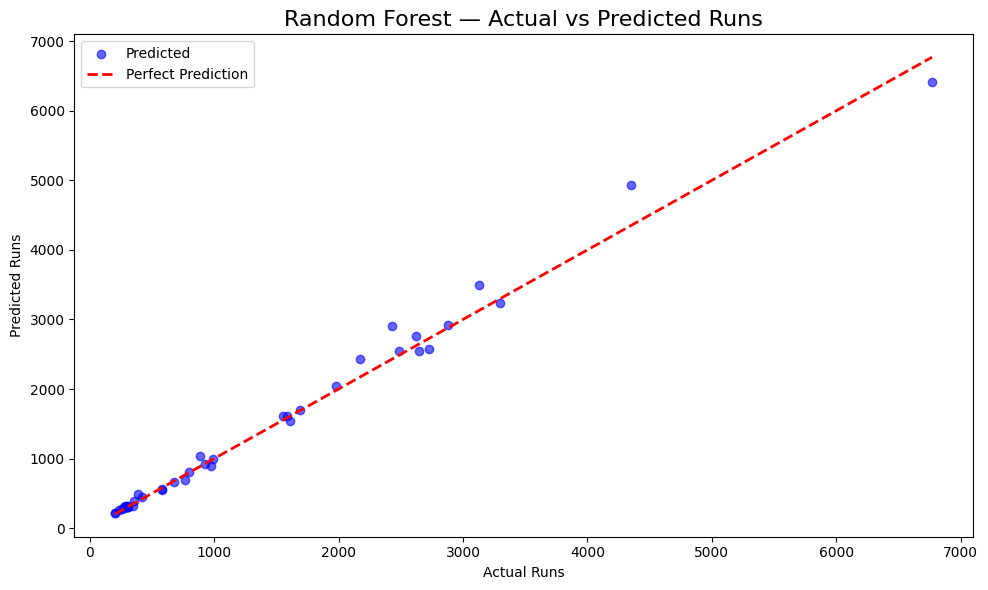

In [23]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, rf_predictions, color='blue', alpha=0.6, label='Predicted')
plt.plot([y_test.min(), y_test.max()], 
         [y_test.min(), y_test.max()], 
         'r--', linewidth=2, label='Perfect Prediction')
plt.title('Random Forest — Actual vs Predicted Runs', fontsize=16)
plt.xlabel('Actual Runs')
plt.ylabel('Predicted Runs')
plt.legend()
plt.tight_layout()
plt.show()

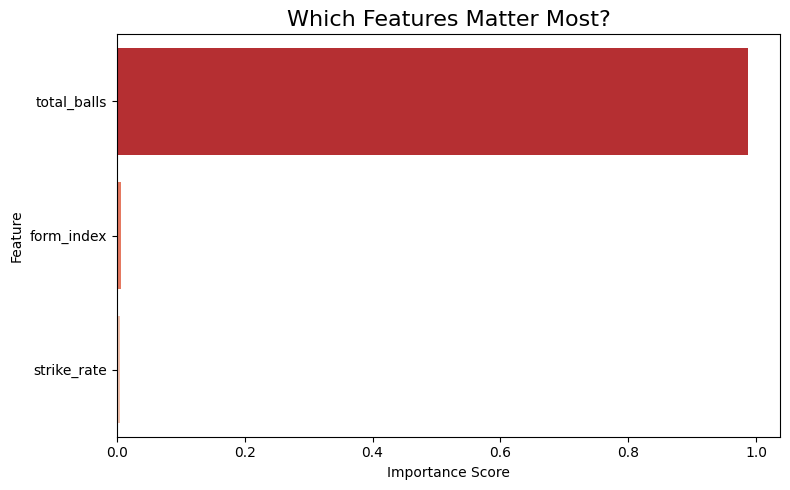

       feature  importance
0  total_balls    0.987783
2   form_index    0.006926
1  strike_rate    0.005291


In [24]:
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x='importance', y='feature', data=feature_importance,
            hue='feature', palette='Reds_r', legend=False)
plt.title('Which Features Matter Most?', fontsize=16)
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

print(feature_importance)

toss_match_winner
True     554
False    541
Name: count, dtype: int64


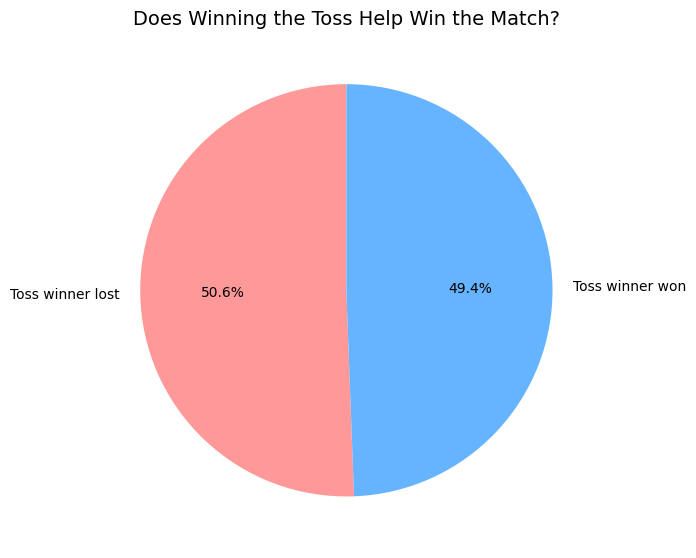

In [25]:
matches['toss_match_winner'] = matches['toss_winner'] == matches['winner']

toss_win = matches['toss_match_winner'].value_counts()
print(toss_win)

plt.figure(figsize=(7, 7))
plt.pie(toss_win.values, 
        labels=['Toss winner lost', 'Toss winner won'], 
        autopct='%1.1f%%',
        colors=['#ff9999','#66b3ff'],
        startangle=90)
plt.title('Does Winning the Toss Help Win the Match?', fontsize=14)
plt.tight_layout()
plt.show()

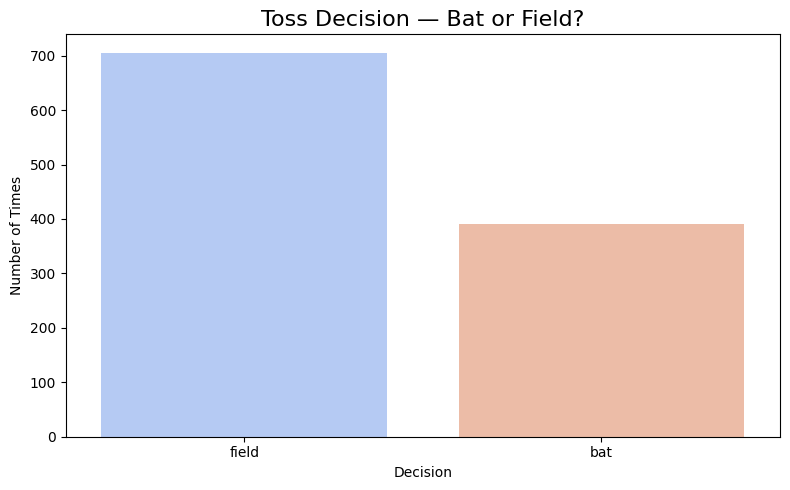

toss_decision
field    704
bat      391
Name: count, dtype: int64


In [26]:
plt.figure(figsize=(8, 5))
toss_decision = matches['toss_decision'].value_counts()
sns.barplot(x=toss_decision.index, y=toss_decision.values,
            hue=toss_decision.index, palette='coolwarm', legend=False)
plt.title('Toss Decision — Bat or Field?', fontsize=16)
plt.xlabel('Decision')
plt.ylabel('Number of Times')
plt.tight_layout()
plt.show()

print(toss_decision)

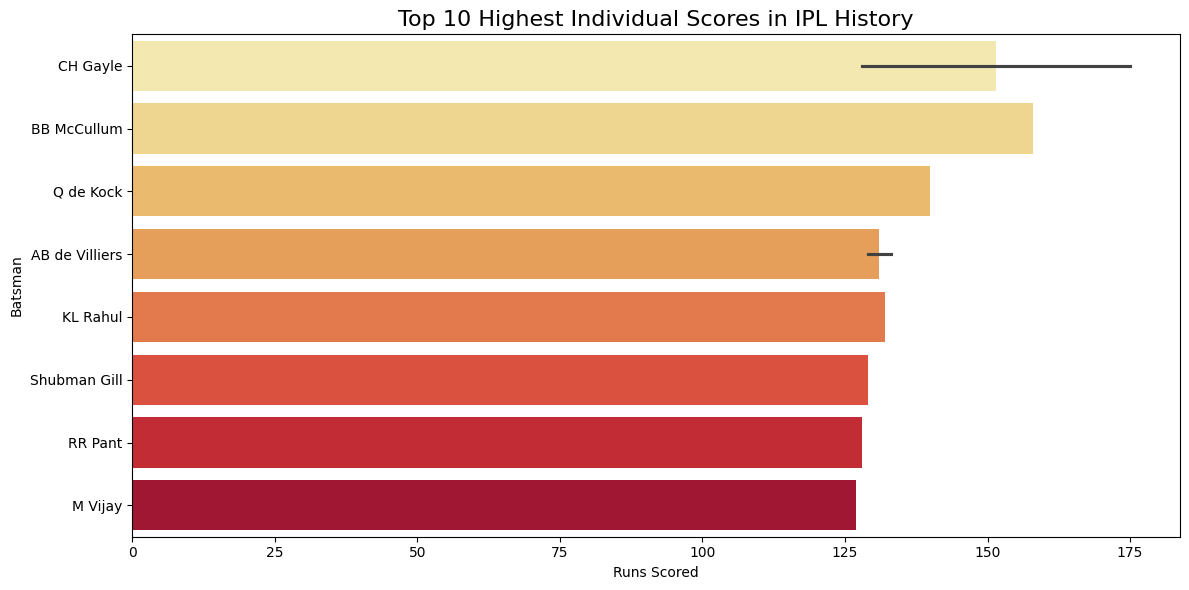

               batter  batsman_runs
5302         CH Gayle           175
2         BB McCullum           158
14108       Q de Kock           140
7528   AB de Villiers           133
11583        KL Rahul           132
15383    Shubman Gill           129
8359   AB de Villiers           129
4687         CH Gayle           128
10149         RR Pant           128
2237          M Vijay           127


In [27]:
highest_scores = deliveries.groupby(['match_id', 'batter'])['batsman_runs'].sum().reset_index()
highest_scores = highest_scores.sort_values('batsman_runs', ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x='batsman_runs', y='batter', data=highest_scores,
            hue='batter', palette='YlOrRd', legend=False)
plt.title('Top 10 Highest Individual Scores in IPL History', fontsize=16)
plt.xlabel('Runs Scored')
plt.ylabel('Batsman')
plt.tight_layout()
plt.show()

print(highest_scores[['batter', 'batsman_runs']])

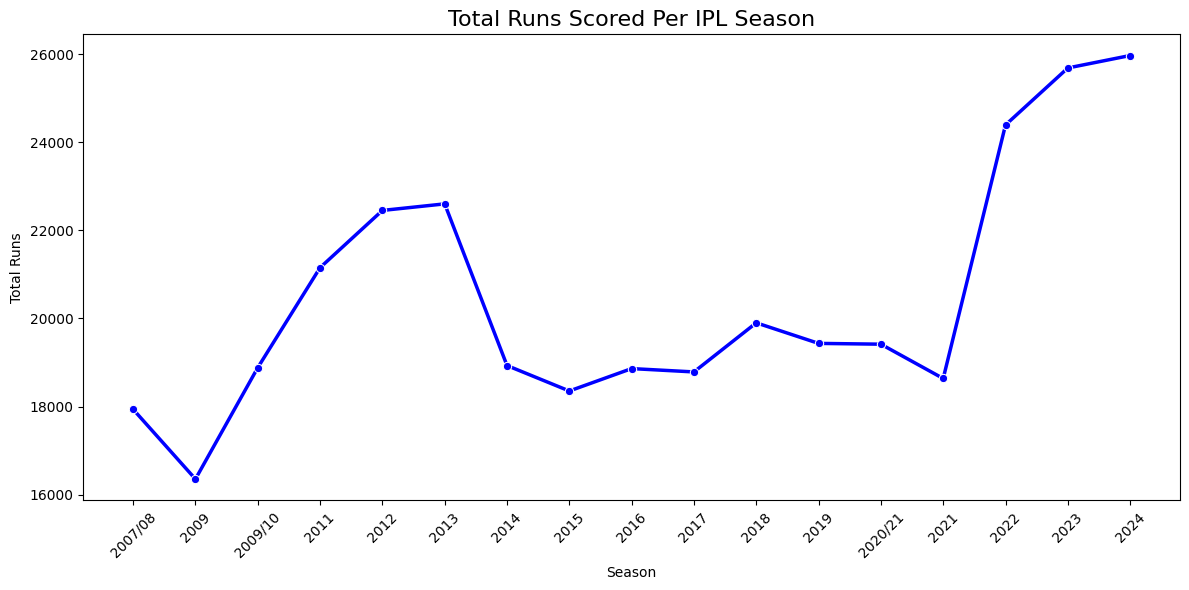

In [28]:
# Merge deliveries with matches to get season info
season_runs = deliveries.merge(matches[['id', 'season']], 
                                left_on='match_id', right_on='id')

runs_per_season = season_runs.groupby('season')['total_runs'].sum().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(x='season', y='total_runs', data=runs_per_season, 
             marker='o', color='blue', linewidth=2.5)
plt.title('Total Runs Scored Per IPL Season', fontsize=16)
plt.xlabel('Season')
plt.ylabel('Total Runs')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

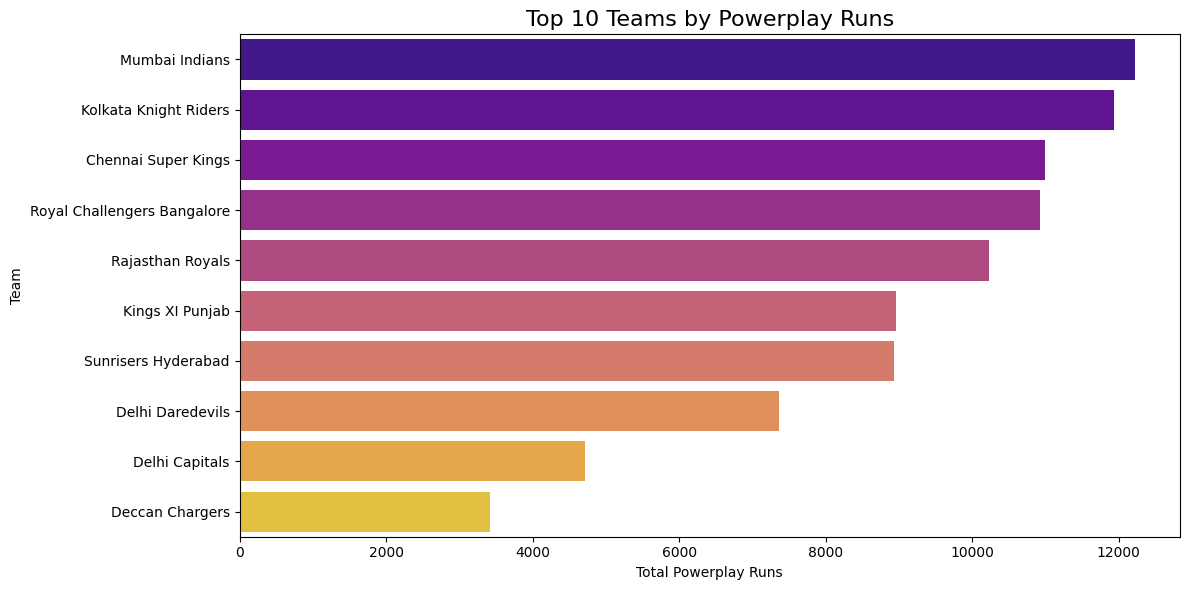

batting_team
Mumbai Indians                 12225
Kolkata Knight Riders          11941
Chennai Super Kings            10991
Royal Challengers Bangalore    10919
Rajasthan Royals               10226
Kings XI Punjab                 8954
Sunrisers Hyderabad             8937
Delhi Daredevils                7360
Delhi Capitals                  4709
Deccan Chargers                 3417
Name: total_runs, dtype: int64


In [29]:
powerplay = deliveries[deliveries['over'] < 6]
powerplay_runs = powerplay.groupby('batting_team')['total_runs'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=powerplay_runs.values, y=powerplay_runs.index,
            hue=powerplay_runs.index, palette='plasma', legend=False)
plt.title('Top 10 Teams by Powerplay Runs', fontsize=16)
plt.xlabel('Total Powerplay Runs')
plt.ylabel('Team')
plt.tight_layout()
plt.show()

print(powerplay_runs)